# Geothermal Suitability Screening — Po Plain (Piemonte)

This notebook walks through the full screening workflow:

1. Load and validate the BHT + coordinates datasets
2. Screen every well into a suitability class
3. Explore the depth–temperature structure
4. Interpolate the geothermal gradient and validate it with LOOCV
5. Build the interactive map

> A regional **screening aid**, not a site-specific feasibility study.

In [1]:
import sys
sys.path.insert(0, "../src")

from gsp.pipeline import run_pipeline
from gsp.viz.charts import depth_temperature_scatter, suitability_ranking, power_search_curve
from gsp.viz.maps import build_map

out = run_pipeline(interpolate=True)
print(f"{len(out.results)} wells screened")

31 wells screened


## 1. Screening results

In [2]:
import pandas as pd
df = pd.DataFrame([{
    "Well": r.well, "Province": r.province, "Depth (m)": r.depth_m,
    "T raw": r.t_raw_c, "T corrected": r.t_corrected_c,
    "Gradient": r.gradient_c_per_km, "Suitability": r.suitability.value,
} for r in out.results])
df.head(10)

,Well,Province,Depth (m),T raw,T corrected,Gradient,Suitability
0,SALI VERCELLESE 1,VERCELLI,4742.80,127.00,140.07,26.37,Power Generation
1,VOLPEDO 4,ALESSANDRIA,5245.00,113.00,123.72,20.73,Power Generation
2,SOMMARIVA DEL BOSCO 1,CUNEO,3793.30,103.55,110.31,25.13,Direct Use
3,TRECATE 9ST,NOVARA,3810.00,94.00,103.32,23.18,Direct Use
4,TRECATE 10,NOVARA,3759.00,92.00,99.77,22.55,Direct Use
5,GALLIATE 1,NOVARA,3467.00,90.00,99.29,24.31,Direct Use
6,DESANA 1,VERCELLI,3200.40,84.00,93.57,24.55,Direct Use
7,ROMENTINO 1,NOVARA,3642.70,83.00,91.81,21.09,Direct Use
8,TRECATE A,NOVARA,2497.00,79.00,88.40,29.40,Direct Use
9,S.SEBASTIANO 1,ALESSANDRIA,3208.35,76.47,83.22,21.26,Direct Use


In [3]:
from collections import Counter
Counter(r.suitability.value for r in out.results)

Counter({'Direct Use': 17,
         'Ground Source Heat Pump': 9,
         'Below Threshold': 3,
         'Power Generation': 2})

## 2. Wells ranked by corrected temperature

In [4]:
suitability_ranking(out.results)

## 3. Depth vs temperature

The correction shift (raw → corrected) is shown as a faint line per reading.

In [5]:
depth_temperature_scatter(out.measurements)

## 4. Interpolation validation

We interpolate the **geothermal gradient** (depth-normalised), not raw
temperature. The IDW power is chosen by minimising leave-one-out RMSE.

In [6]:
print(f"Selected IDW power: {out.field.best_power}")
print(f"LOOCV gradient RMSE: {out.field.loocv_rmse_c_per_km} C/km")
print(f"LOOCV gradient MAE:  {out.field.loocv_mae_c_per_km} C/km")
power_search_curve(out.power_search.sweep, out.field.best_power)

Selected IDW power: 1.0
LOOCV gradient RMSE: 3.53 C/km
LOOCV gradient MAE:  2.8 C/km


**Interpretation.** The gradient RMSE (~3.5 °C/km) is close to the gradient's
own spatial spread, so the sparse network resolves little structure beyond the
regional mean. The interpolated surface is a screening visualisation, not a
predictive model — per-well classes rest on measured data.

## 5. Interactive map


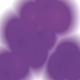

In [7]:
all_meas = {}
for m in out.measurements:
    all_meas.setdefault(m.well, []).append((m.depth_m, m.t_raw_c, m.t_corrected_c))

fmap = build_map(out.results, out.field, reference_depth_m=2000.0, all_measurements=all_meas)
fmap